In [42]:
## Load my files ##
import sys
sys.path.append('..')
from utils import get_sequence

## Load standard files ##
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim.lr_scheduler as lr_scheduler
from torch import from_numpy as tnsr
from scipy.stats import bernoulli
import torch.nn as nn
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist as dist
from sklearn.metrics.pairwise import cosine_similarity
from scipy.signal import find_peaks
from scipy.spatial.distance import cosine
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import torch.nn.functional as F
from collections import deque
import random 
import pickle 

In [43]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")  # works only with NVIDIA GPUs (not on Mac)
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: mps


In [44]:
# tokens start from 1
class Dataset_converter(Dataset):
    def __init__(self, data, working_memory=1, short_term_memory=1):
        
        self.X = np.zeros((((len(data)-working_memory-short_term_memory)), short_term_memory))
        self.y = np.zeros((((len(data)-working_memory-short_term_memory)), 1))

        for ii in range(self.X.shape[0]):
            for jj in range(self.X.shape[1]):
                self.X[ii,jj] = \
                ord(data[ii+jj])-65
      
            self.y[ii] = \
                ord(data[ii+jj+1])-65

        self.X = tnsr(self.X).long()
        self.y = tnsr(self.y).long()

    def __getitem__(self, index):
        return self.X[index], self.y[index]

    def __len__(self):
        return self.X.shape[0]

In [45]:
class RNNEncoder(nn.Module):
    def __init__(self, vocab_size, hidden_size, context_size, context_projection_size=0, use_embedding=False, embedding_dim=10):
        super().__init__()
        self.use_embedding = use_embedding

        if context_projection_size != 0:
            self.context_layer = nn.Linear(context_size, context_projection_size)

        if self.use_embedding:
            self.embedding = nn.Embedding(vocab_size, embedding_dim)
            self.rnn = nn.RNN(embedding_dim+context_projection_size, hidden_size, batch_first=True, nonlinearity='tanh')
        else:
            self.input_projection = nn.Linear(vocab_size, embedding_dim)
            self.rnn = nn.RNN(embedding_dim+context_projection_size, hidden_size, batch_first=True, nonlinearity='tanh')
        
        self.linear = nn.Linear(hidden_size, vocab_size)

        ### use orthogonal initialization of weights ### 
        for name, param in self.rnn.named_parameters():
            if "weight_hh" in name:
                nn.init.orthogonal_(param)
            elif "weight_ih" in name:
                nn.init.xavier_uniform_(param)
            elif "bias" in name:
                nn.init.zeros_(param)
    
    def forward(self, x, context=None, h=None):
        if context != None:
            context_out = self.context_layer(context)
            if self.use_embedding:
                embedded = self.embedding(x)
                # print(embedded.size(), context_out.size())
                context_expanded = context_out.unsqueeze(1).expand(-1, embedded.size(1), -1)
                embedded = torch.cat((embedded, context_expanded), dim=2)
                out, h = self.rnn(embedded, h)
            else:
                embedded = self.input_projection(x)
                context_expanded = context_out.unsqueeze(1).expand(-1, embedded.size(1), -1)
                embedded = torch.cat((embedded, context_expanded), dim=2)
                out, h = self.rnn(embedded, h)
        else:
            if self.use_embedding:
                embedded = self.embedding(x)
                out, h = self.rnn(embedded, h)
            else:
                embedded = self.input_projection(x)
                out, h = self.rnn(embedded, h)

        out = self.linear(out[:,-1,:])

        return out, h  
    
class RNNDecoder(nn.Module):
    def __init__(self, vocab_size, hidden_size, use_embedding=False, embedding_dim=10):
        super().__init__()
        self.use_embedding = use_embedding

        if self.use_embedding:
            self.embedding = nn.Embedding(vocab_size, embedding_dim)
            self.rnn = nn.RNN(embedding_dim, hidden_size, batch_first=True, nonlinearity='tanh')
        else:
            self.rnn = nn.RNN(vocab_size, hidden_size, batch_first=True, nonlinearity='tanh')

        self.fc = nn.Linear(hidden_size, vocab_size)

        ### use orthogonal initialization of weights ###
        for name, param in self.rnn.named_parameters():
            if "weight_hh" in name:
                nn.init.orthogonal_(param)
            elif "weight_ih" in name:
                nn.init.xavier_uniform_(param)
            elif "bias" in name:
                nn.init.zeros_(param)
    
    def forward(self, x, h):
        if self.use_embedding:
            embedded = self.embedding(x)
            out, _ = self.rnn(embedded, h)
        else:
            out, _ = self.rnn(x, h)

        return self.fc(out) 
    
class RNNAutoencoder(nn.Module):
    def __init__(self, vocab_size, hidden_size, context_size, context_projection_size, use_embedding=False, embedding_dim=10 ):
        super().__init__()
        self.encoder = RNNEncoder(vocab_size, hidden_size, context_size, context_projection_size, use_embedding, embedding_dim)
        self.decoder = RNNDecoder(vocab_size, hidden_size, use_embedding, embedding_dim)
    
    def forward(self, x, decoder_input, context, h=None):
        next_token, h = self.encoder(x, context, h)
        decoder_output = self.decoder(decoder_input, h)
        return next_token, decoder_output, h

In [46]:
def path_finder_loss(y_pred, decoder_output, y_target, decoder_target):
    ce1 = F.cross_entropy(y_pred.view(-1, y_pred.size(-1)), y_target.view(-1))
    ce2 = F.cross_entropy(decoder_output.view(-1, decoder_output.size(-1)), decoder_target.view(-1))

    return (ce1+ce2)/2

In [47]:
def path_finder_loss_mse(y_pred, decoder_output, y_target, decoder_target):
    ce1 = F.mse_loss(y_pred.view(-1), y_target.view(-1))
    ce2 = F.mse_loss(decoder_output.view(-1), decoder_target.view(-1))

    return (ce1+ce2)/2

In [48]:
def train_layer(model, optimizer, criterion, X, y, context=None, h=None, layer=0):
    if layer == 0:
        decoder_input = torch.cat([torch.zeros((1, 1), dtype=torch.long), X[:, :-1]], dim=1)
    else:
        decoder_input = torch.cat([torch.zeros((1, 1, X.shape[2]), dtype=torch.long), X[:, :-1]], dim=1)

    decoder_target = X.flip(1)

    optimizer.zero_grad()
    y_pred, decoder_output, h = model(X, decoder_input, context, h)
    # print(y_pred[0], 'y_pred', y[0], 'y', decoder_output[0], decoder_target[0])
    loss = criterion(y_pred[0], decoder_output[0], y[0], decoder_target[0])     
    loss.backward()

    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    if layer == 0:
        with torch.no_grad():
            if y[0] == y_pred[0].argmax():
                correct = 1
            else:
                correct = 0
        
        return correct, h.detach()
    
    return h.detach()
        

In [51]:
reps = 10
res = []

for rep in range(reps):
    print('Doing rep ', rep)

    total_samples = 50000
    short_term_memory = 3
    n_member = 3
    n_community = 2

    total_layers = 4
    model = {}
    input_buffer = {}
    target_buffer = {}
    context = {}
    h = {}
    vocab_size = n_member*n_community+1
    embedding_dim = 10
    context_projection_size = 10
    downsample_factor = short_term_memory
    lr = [1e-3,1e-3,1e-3,1e-3,1e-3]
    hidden_size = [50, 50, 50, 50, 50]
    optimizers = []
    criteria = []

    for layer in range(total_layers):  
        if layer == 0:
            model[layer] = RNNAutoencoder(vocab_size, hidden_size[layer], hidden_size[layer+1], context_projection_size, use_embedding=True, embedding_dim=embedding_dim)
            criteria.append(
                path_finder_loss
            )
        else:
            if layer == total_layers-1:
                model[layer] = RNNAutoencoder(hidden_size[layer-1], hidden_size[layer], 0, context_projection_size=0, embedding_dim=embedding_dim)
            else:
                model[layer] = RNNAutoencoder(hidden_size[layer-1], hidden_size[layer], hidden_size[layer+1], context_projection_size, embedding_dim=embedding_dim)

            context[layer-1] = torch.zeros((1,hidden_size[layer]))
            input_buffer[layer] = deque(
                [torch.zeros((hidden_size[layer-1])) for _ in range(short_term_memory)],
                maxlen=short_term_memory
            )
            target_buffer[layer] = torch.zeros((hidden_size[layer-1]))
            criteria.append(
                path_finder_loss_mse
            )

        optimizers.append(
            torch.optim.Adam(model[layer].parameters(), lr=lr[layer], weight_decay=1e-8)
        )

        h[layer] = None

    context[layer] = None


    ### train on the source task ###

    ### handle data ###
    data = get_sequence(total_samples, n_community, n_member, train=False)
    data_set = Dataset_converter(data, 1, short_term_memory)
    train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

    ### train the model ###
    correct = np.zeros(1000,dtype=float)
    decoder_correct = np.zeros(1000,dtype=float)
    test_acc = []
    test_acc_decoder = []

    total = 0
    total_layer1 = 0
    

    for X, y in train_loader:
        for layer in range(total_layers):
            if layer == 0:
                accurate, h[layer] = train_layer(model[0], optimizers[0], criteria[0], X, y, context[0], h[layer])

                correct[total%1000] = accurate

            elif total%(downsample_factor**layer)==0:
                input_buffer[layer].append(
                    target_buffer[layer].clone()
                )
                target_buffer[layer] = h[layer-1][0][0]

                h[layer] = train_layer(
                    model[layer], optimizers[layer], criteria[layer], torch.stack(list(input_buffer[layer])).unsqueeze(0), 
                    torch.stack(list(target_buffer[layer])).unsqueeze(0), context[layer], h[layer], layer=layer
                )
                context[layer-1][0] = h[layer][0][0]
                 
        total += 1
        
        test_acc.append(
                np.sum(correct)/total if total<1000 else np.sum(correct)/1000
            )
            
        if total%1000 == 0:
            print(f'Iter : {total+1}, accuracy: {test_acc[-1]:.4f}')

    
    ### re-initialize the first layer ###
    # model[0] = RNNAutoencoder(vocab_size, hidden_size[0], hidden_size[1], context_projection_size, use_embedding=True, embedding_dim=embedding_dim)
    lr = [1e-3,0,0,0,0]
    ### handle data ###
    data = get_sequence(total_samples, n_community, n_member)
    data_set = Dataset_converter(data, 1, short_term_memory)
    train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

    ### train the model ###
    correct = np.zeros(1000,dtype=float)
    decoder_correct = np.zeros(1000,dtype=float)
    test_acc = []
    test_acc_decoder = []

    total = 0
    total_layer1 = 0
    

    for X, y in train_loader:
        for layer in range(total_layers):
            if layer == 0:
                accurate, h[layer] = train_layer(model[0], optimizers[0], criteria[0], X, y, context[0], h[layer])

                correct[total%1000] = accurate

            elif total%(downsample_factor**layer)==0:
                input_buffer[layer].append(
                    target_buffer[layer].clone()
                )
                target_buffer[layer] = h[layer-1][0][0]

                h[layer] = train_layer(
                    model[layer], optimizers[layer], criteria[layer], torch.stack(list(input_buffer[layer])).unsqueeze(0), 
                    torch.stack(list(target_buffer[layer])).unsqueeze(0), context[layer], h[layer], layer=layer
                )
                context[layer-1][0] = h[layer][0][0]
                 
        total += 1
        
        test_acc.append(
                np.sum(correct)/total if total<1000 else np.sum(correct)/1000
            )
            
        if total%1000 == 0:
            print(f'Iter : {total+1}, accuracy: {test_acc[-1]:.4f}')

    res.append(
        test_acc
    )


Doing rep  0
Iter : 1001, accuracy: 0.6880
Iter : 2001, accuracy: 0.7440
Iter : 3001, accuracy: 0.7570
Iter : 4001, accuracy: 0.7700
Iter : 5001, accuracy: 0.8350
Iter : 6001, accuracy: 0.8550
Iter : 7001, accuracy: 0.8390
Iter : 8001, accuracy: 0.8440
Iter : 9001, accuracy: 0.8560
Iter : 10001, accuracy: 0.8510
Iter : 11001, accuracy: 0.8750
Iter : 12001, accuracy: 0.8800
Iter : 13001, accuracy: 0.8730
Iter : 14001, accuracy: 0.8670
Iter : 15001, accuracy: 0.8500
Iter : 16001, accuracy: 0.8620
Iter : 17001, accuracy: 0.8760
Iter : 18001, accuracy: 0.8930
Iter : 19001, accuracy: 0.8730
Iter : 20001, accuracy: 0.8700
Iter : 21001, accuracy: 0.8850
Iter : 22001, accuracy: 0.8820
Iter : 23001, accuracy: 0.8650
Iter : 24001, accuracy: 0.8690
Iter : 25001, accuracy: 0.8720
Iter : 26001, accuracy: 0.8980
Iter : 27001, accuracy: 0.8920
Iter : 28001, accuracy: 0.8660
Iter : 29001, accuracy: 0.8700
Iter : 30001, accuracy: 0.8670
Iter : 31001, accuracy: 0.8710
Iter : 32001, accuracy: 0.8820
Iter

In [52]:
with open('../pickle_files/transfer2_layer4.pickle', 'wb') as f:
    pickle.dump(res, f)

In [34]:
reps = 10
res = []

for rep in range(reps):
    print('Doing rep ', rep)

    total_samples = 50000
    short_term_memory = 3
    n_member = 3
    n_community = 2

    total_layers = 4
    model = {}
    input_buffer = {}
    target_buffer = {}
    context = {}
    h = {}
    vocab_size = n_member*n_community+1
    embedding_dim = 10
    context_projection_size = 10
    downsample_factor = short_term_memory
    lr = [1e-3,1e-3,1e-3,1e-3,1e-3]
    hidden_size = [50, 100, 200, 300, 400]
    optimizers = []
    criteria = []

    for layer in range(total_layers):  
        if layer == 0:
            model[layer] = RNNAutoencoder(vocab_size, hidden_size[layer], hidden_size[layer+1], context_projection_size, use_embedding=True, embedding_dim=embedding_dim)
            criteria.append(
                path_finder_loss
            )
        else:
            if layer == total_layers-1:
                model[layer] = RNNAutoencoder(hidden_size[layer-1], hidden_size[layer], 0, context_projection_size=0)
            else:
                model[layer] = RNNAutoencoder(hidden_size[layer-1], hidden_size[layer], hidden_size[layer+1], context_projection_size)

            context[layer-1] = torch.zeros((1,hidden_size[layer]))
            input_buffer[layer] = deque(
                [torch.zeros((hidden_size[layer-1])) for _ in range(short_term_memory)],
                maxlen=short_term_memory
            )
            target_buffer[layer] = torch.zeros((hidden_size[layer-1]))
            criteria.append(
                path_finder_loss_mse
            )

        optimizers.append(
            torch.optim.Adam(model[layer].parameters(), lr=lr[layer], weight_decay=1e-8)
        )

        h[layer] = None

    context[layer] = None

    ### handle data ###
    data = get_sequence(total_samples, n_community, n_member)
    data_set = Dataset_converter(data, 1, short_term_memory)
    train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

    ### train the model ###
    correct = np.zeros(1000,dtype=float)
    decoder_correct = np.zeros(1000,dtype=float)
    test_acc = []
    test_acc_decoder = []

    total = 0
    total_layer1 = 0
    

    for X, y in train_loader:
        for layer in range(total_layers):
            if layer == 0:
                accurate, h[layer] = train_layer(model[0], optimizers[0], criteria[0], X, y, context[0], h[layer])

                correct[total%1000] = accurate

            elif total%(downsample_factor*layer)==0:
                input_buffer[layer].append(
                    target_buffer[layer].clone()
                )
                target_buffer[layer] = h[layer-1][0][0]

                h[layer] = train_layer(
                    model[layer], optimizers[layer], criteria[layer], torch.stack(list(input_buffer[layer])).unsqueeze(0), 
                    torch.stack(list(target_buffer[layer])).unsqueeze(0), context[layer], h[layer], layer=layer
                )
                context[layer-1][0] = h[layer][0][0]
                 
        total += 1
        
        test_acc.append(
                np.sum(correct)/total if total<1000 else np.sum(correct)/1000
            )
            
        if total%1000 == 0:
            print(f'Iter : {total+1}, accuracy: {test_acc[-1]:.4f}')

    res.append(
        test_acc
    )


Doing rep  0
Iter : 1001, accuracy: 0.5930
Iter : 2001, accuracy: 0.6810
Iter : 3001, accuracy: 0.6880
Iter : 4001, accuracy: 0.6970
Iter : 5001, accuracy: 0.6670
Iter : 6001, accuracy: 0.7080
Iter : 7001, accuracy: 0.7090
Iter : 8001, accuracy: 0.7630
Iter : 9001, accuracy: 0.8100
Iter : 10001, accuracy: 0.8250
Iter : 11001, accuracy: 0.8040
Iter : 12001, accuracy: 0.8030
Iter : 13001, accuracy: 0.8100
Iter : 14001, accuracy: 0.8200
Iter : 15001, accuracy: 0.8020
Iter : 16001, accuracy: 0.8040
Iter : 17001, accuracy: 0.8120
Iter : 18001, accuracy: 0.8180
Iter : 19001, accuracy: 0.8180
Iter : 20001, accuracy: 0.8260
Iter : 21001, accuracy: 0.8070
Iter : 22001, accuracy: 0.8050
Iter : 23001, accuracy: 0.8130
Iter : 24001, accuracy: 0.8150
Iter : 25001, accuracy: 0.8110
Iter : 26001, accuracy: 0.8120
Iter : 27001, accuracy: 0.8150
Iter : 28001, accuracy: 0.8080
Iter : 29001, accuracy: 0.8090
Iter : 30001, accuracy: 0.8040
Iter : 31001, accuracy: 0.8150
Iter : 32001, accuracy: 0.8190
Iter

In [35]:
with open('../pickle_files/transfer2_control_layer4.pickle', 'wb') as f:
    pickle.dump(res, f)

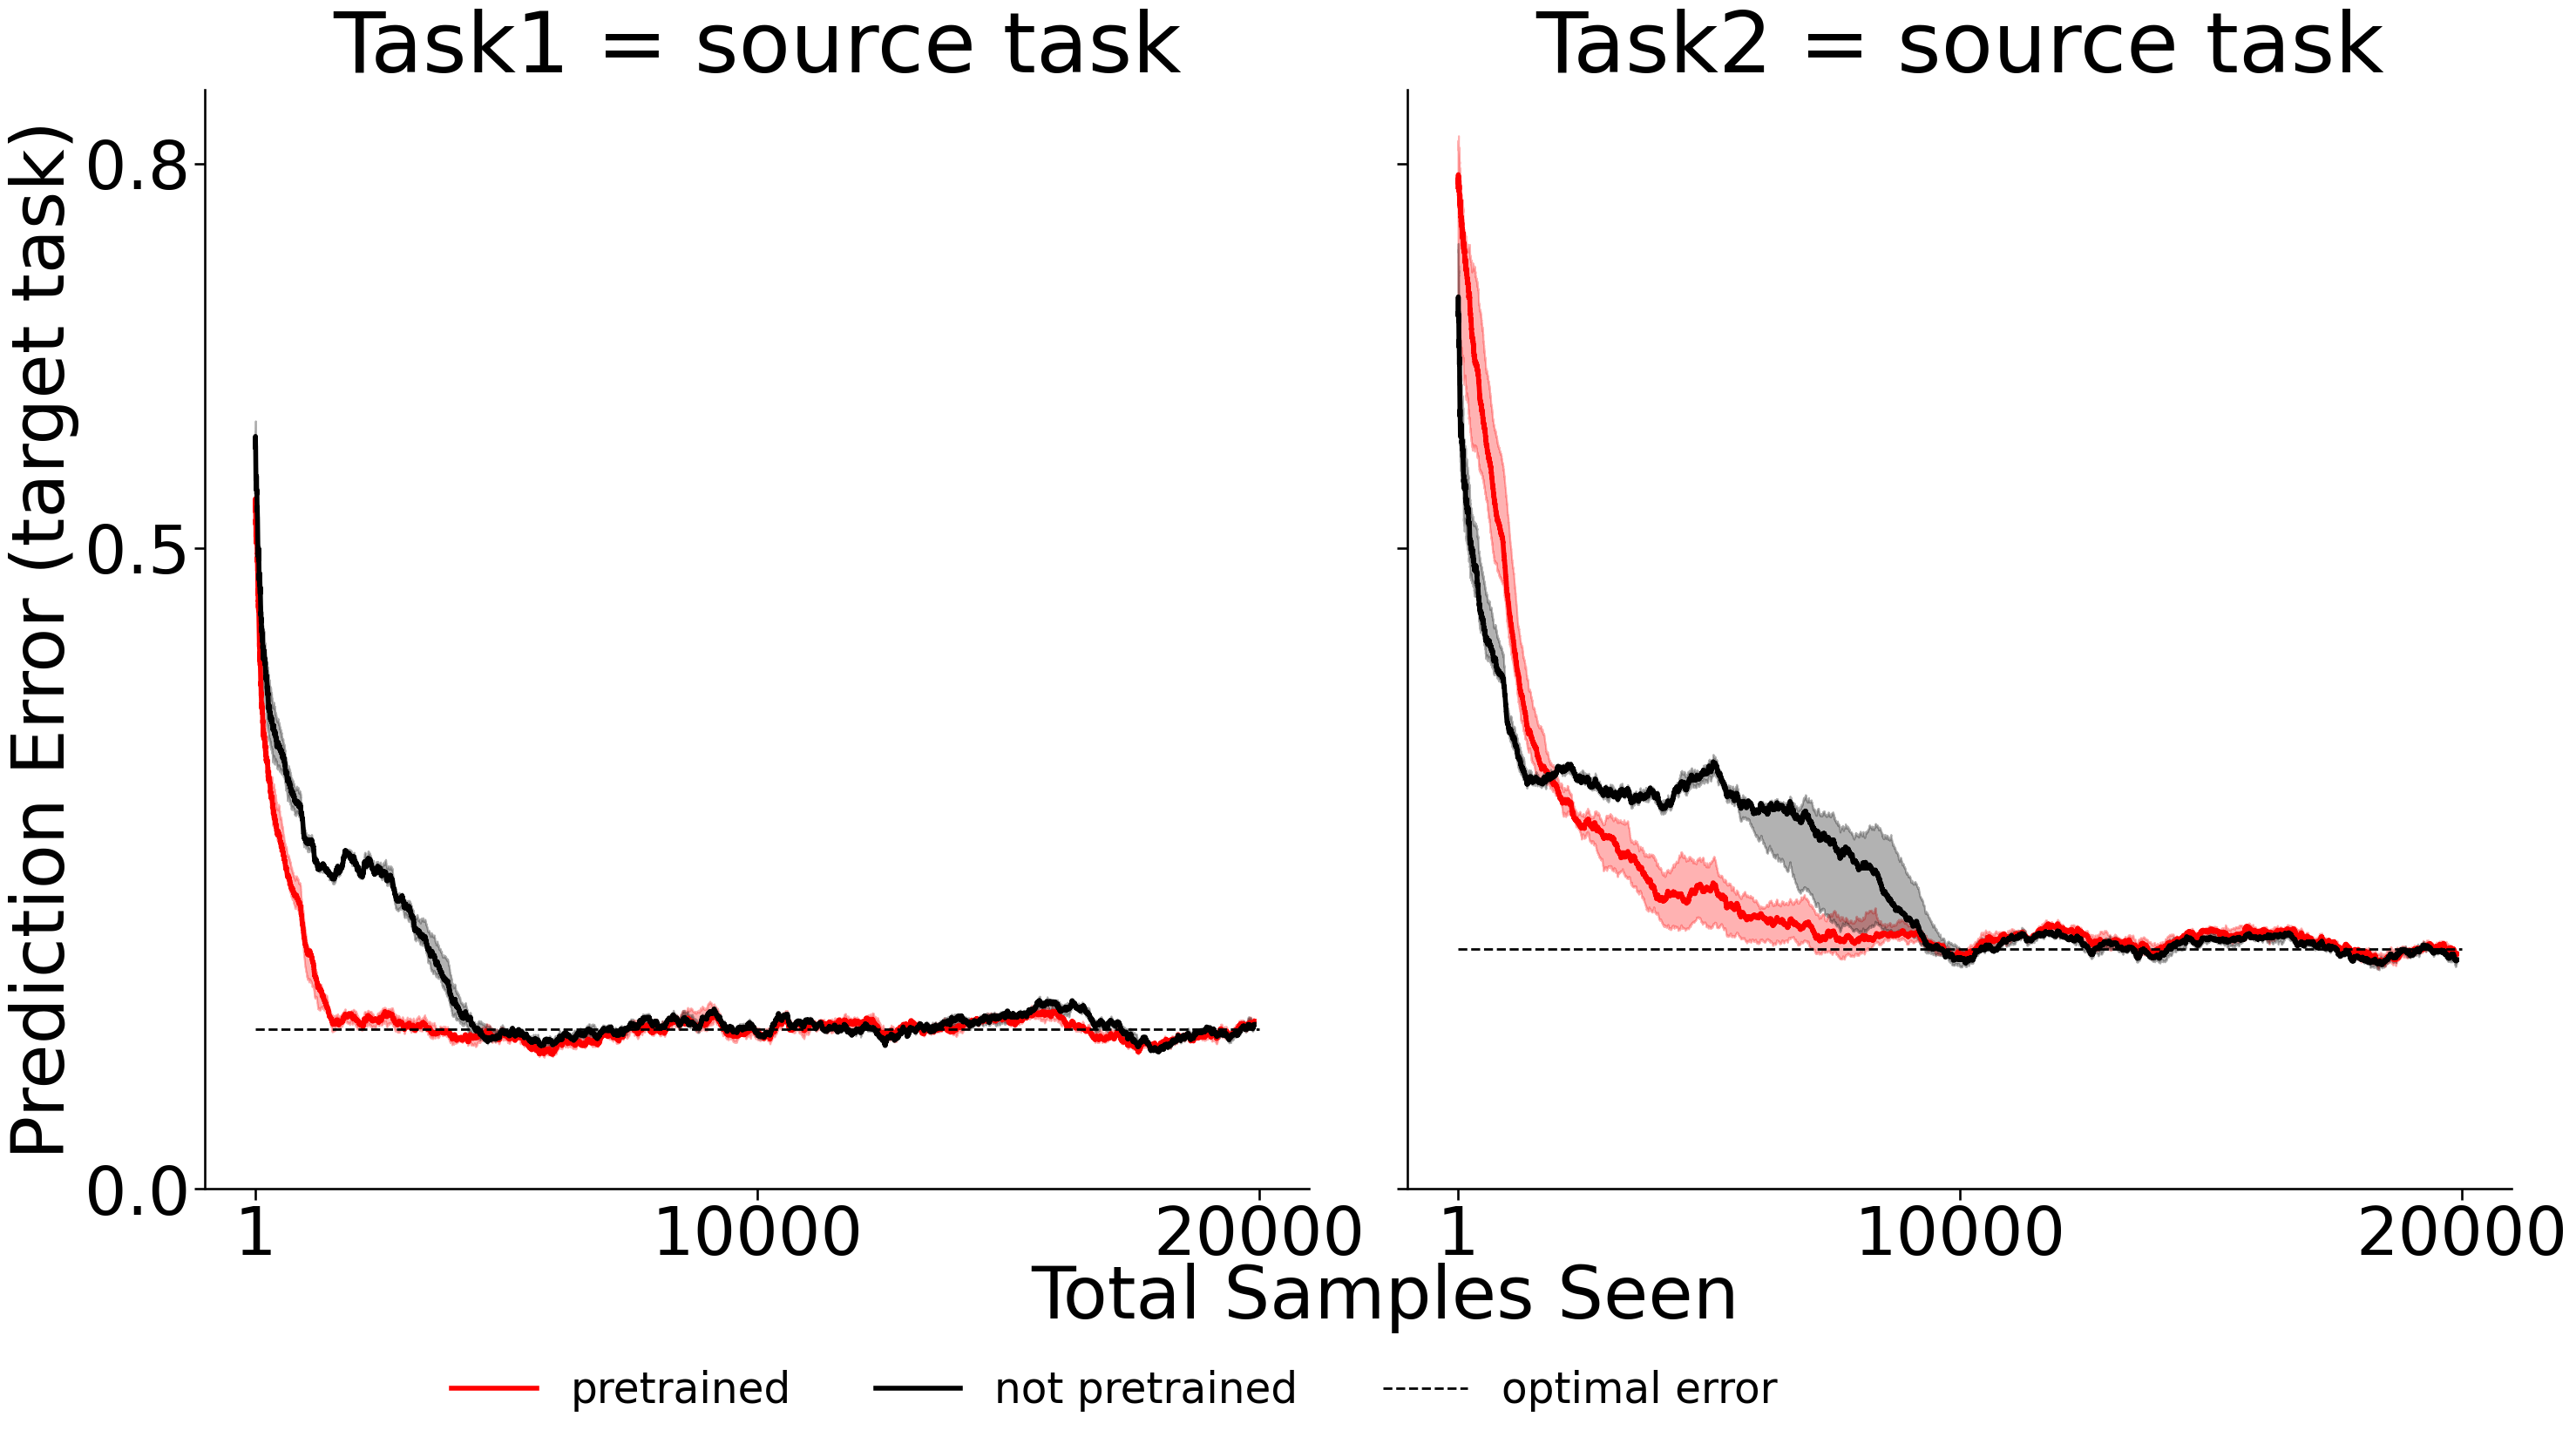

In [91]:
total_samples = 20000

with open('../pickle_files/transfer1_layer4.pickle', 'rb') as f:
    res_transfer1 = 1 - np.array(pickle.load(f))[:,100:total_samples]

with open('../pickle_files/transfer1_control_layer4.pickle', 'rb') as f:
    res_transfer1_control = 1 - np.array(pickle.load(f))[:,100:total_samples]

with open('../pickle_files/transfer2_layer4.pickle', 'rb') as f:
    res_transfer2 = 1 - np.array(pickle.load(f))[:,100:total_samples]

with open('../pickle_files/transfer2_control_layer4.pickle', 'rb') as f:
    res_transfer2_control = 1 - np.array(pickle.load(f))[:,100:total_samples]

clr = ['b', 'y', 'g', 'c', 'm']


fig, ax = plt.subplots(1, 2, figsize=(30, 15), sharey=True, sharex=True)
sns.set_context('talk')
fontsize=60


ax[0].plot(np.arange(1,res_transfer1.shape[1]+1), np.median(res_transfer1, axis=0), label='pretrained', linewidth=4, color='r')
ax[0].fill_between(np.arange(1,res_transfer1.shape[1]+1), np.quantile(res_transfer1, [0.25], axis=0)[0], np.quantile(res_transfer1, [0.75], axis=0)[0], alpha=.3, color='r')

ax[0].plot(np.arange(1,res_transfer1_control.shape[1]+1), np.median(res_transfer1_control, axis=0), label='not pretrained', linewidth=4, color='k')
ax[0].fill_between(np.arange(1,res_transfer1_control.shape[1]+1), np.quantile(res_transfer1_control, [0.25], axis=0)[0], np.quantile(res_transfer1_control, [0.75], axis=0)[0], alpha=.3, color='k')

ax[0].hlines(1-0.875, 1, total_samples, linestyle='--', color='black', linewidth=2, label='optimal error')

ax[0].set_title('Task1 = source task', fontsize=fontsize+10)

ax[1].plot(np.arange(1,res_transfer2.shape[1]+1), np.median(res_transfer2, axis=0), linewidth=4, color='r')
ax[1].fill_between(np.arange(1,res_transfer2.shape[1]+1), np.quantile(res_transfer2, [0.25], axis=0)[0], np.quantile(res_transfer2, [0.75], axis=0)[0], alpha=.3, color='r')

ax[1].plot(np.arange(1,res_transfer2_control.shape[1]+1), np.median(res_transfer2_control, axis=0), linewidth=4, color='k')
ax[1].fill_between(np.arange(1,res_transfer2_control.shape[1]+1), np.quantile(res_transfer2_control, [0.25], axis=0)[0], np.quantile(res_transfer2_control, [0.75], axis=0)[0], alpha=.3, color='k')

ax[1].hlines(1-0.8125, 1, total_samples, linestyle='--', color='black', linewidth=2)
ax[1].set_title('Task2 = source task', fontsize=fontsize+10)

for ii in range(2):
    ax[ii].set_yticks([0,.5,.8])
    ax[ii].set_xticks([1,total_samples//2,total_samples])
    right_side = ax[ii].spines["right"]
    right_side.set_visible(False)
    top_side = ax[ii].spines["top"]
    top_side.set_visible(False)

    ax[ii].tick_params(labelsize=fontsize-5)
fig.text(.4,-.02,'Total Samples Seen', fontsize=fontsize)
ax[0].set_ylabel('Prediction Error (target task)', fontsize=fontsize)

leg = fig.legend(bbox_to_anchor=(.7, -.03), bbox_transform=plt.gcf().transFigure,
                        ncol=3, fontsize=35, frameon=False)

plt.tight_layout()
plt.savefig('../plots/HDRNN_transfer_sim.pdf', bbox_inches='tight')